In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Przygotowanie danych

### Pobranie danych z pliku

dict_keys(['__header__', '__version__', '__globals__', 'H'])


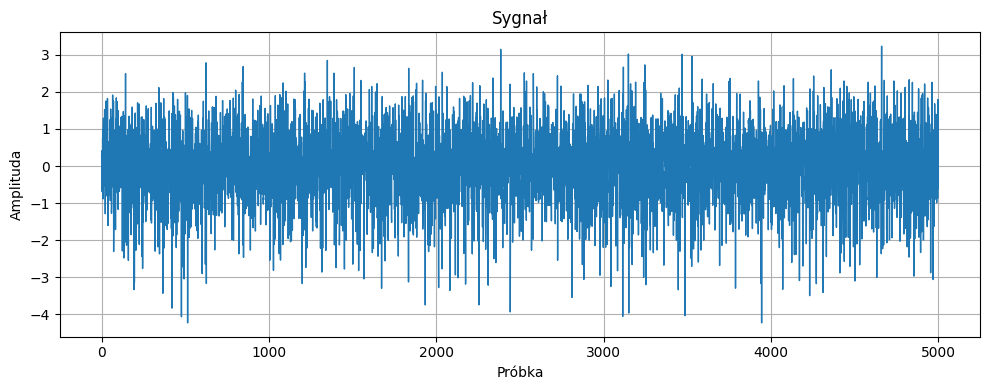

In [175]:
from scipy.io import loadmat

# wczytanie pliku
# data = loadmat('assets/vibration_dataset/Faulty/F1.mat')
data = loadmat('assets/vibration_dataset/Healthy/H1.mat')
print(data.keys())
signal = data["H"][:,1]
plt.figure(figsize=(10, 4))
plt.plot(signal, linewidth=1)
plt.title(f"Sygnał")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()

### Wygenerowanie danych

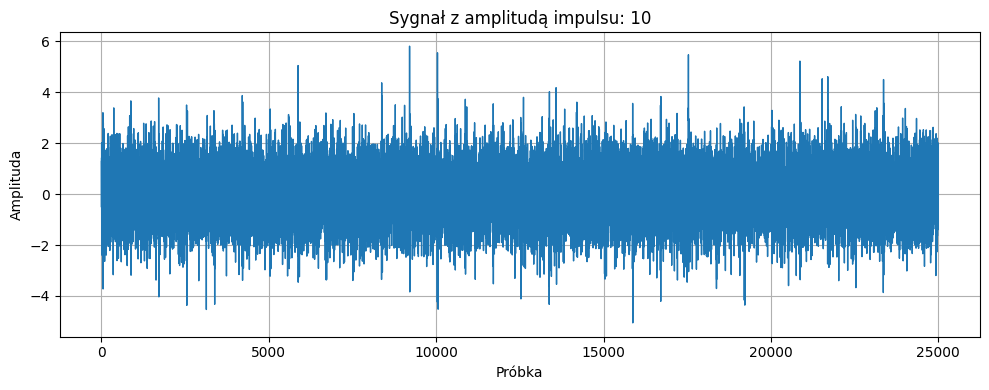

In [2]:
import impuls_simulator as impuls_simulator
B=10
fs=25000
varsize=25000
fmod=30
f_center=2000
bandwidth=500
shift=0
sigma = 3
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)
plt.figure(figsize=(10, 4))
plt.plot(signal, linewidth=1)
plt.title(f"Sygnał z amplitudą impulsu: {B}")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()

## Spektrogram

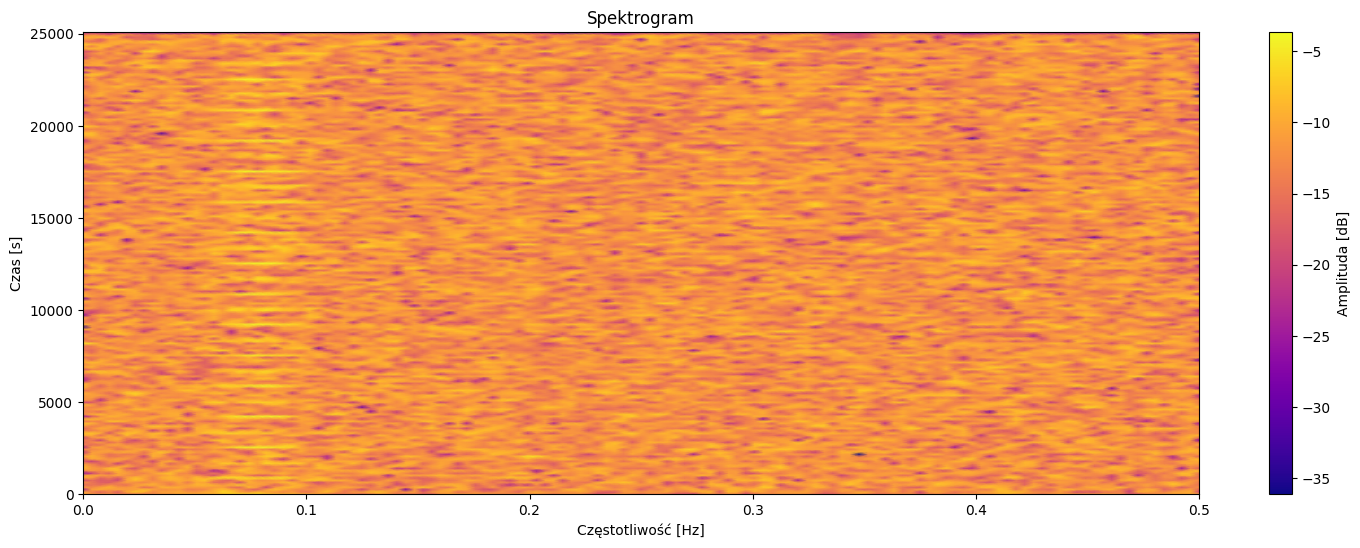

In [3]:
#obliczenie STFT
fs = 1
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
#Wyrysowanie Wykresu
plt.figure(figsize=(18, 6))
plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram')
plt.colorbar(label='Amplituda [dB]')
plt.show()

# Funkcje do analizy

In [4]:
#znajdywanie przedziałów wzrostu
# def spike_detection(data, threshold_factor):
#     data = np.array(data)
#     mean_data = np.mean(data)
#     data -= mean_data
#     threshold = mean_data * threshold_factor
#     above = data > threshold

#     # znajdź przejdział
#     ifb = (0,0)
#     start = None

#     for i, v in enumerate(above):
#         if v:
#             if start is None:
#                 start = i
#         else:
#             if start is not None:
#                 if i-start > ifb[1]-ifb[0]:
#                     ifb = (start, i-1)
#                 start = None
#     if start is not None:
#         if len(data) - start > ifb[1] - ifb[0]:
#             ifb = (start, len(data)-1)
#     return ifb

def spike_interval_by_peak(data, threshold_factor=2):
    data = np.array(data)
    baseline = np.median(data)
    uplift = np.std(data)
    threshold = baseline + threshold_factor*uplift

    # 1. Znajdź największy peak powyżej thresholdu
    idx_peak = np.argmax(data)
    if data[idx_peak] < threshold:
        return None  # brak impulsu

    # 2. Rozszerz w lewo
    left = idx_peak
    while left > 0 and data[left] > threshold:
        left -= 1

    # 3. Rozszerz w prawo
    right = idx_peak
    while right < len(data)-1 and data[right] > threshold:
        right += 1


    return left, right, threshold


In [5]:
def bandpass_filter(signal, fs, f_low, f_high):
    # Wykonanie FFT
    fft_signal = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    
    # Tworzenie maski dla wybranego pasma
    mask = (abs(freqs) >= f_low) & (abs(freqs) <= f_high)
    
    # Aplikacja maski (wyzerowanie składowych poza wybranym pasmem)
    fft_signal_filtered = fft_signal.copy()
    fft_signal_filtered[~mask] = 0
    
    # Odwrotna transformata Fouriera
    filtered_signal = np.real(np.fft.ifft(fft_signal_filtered))
    
    return filtered_signal, freqs, fft_signal, fft_signal_filtered

In [6]:
def selector_analysis(results,filter_threshold, impuls_threshold):

    left, right, threshold = spike_interval_by_peak(results,filter_threshold)

    #filtracja na podstawie otrzymanych granic
    filtered, _, _, _ = bandpass_filter(signal, fs, array_freq[left], array_freq[right])
    sigma = np.std(filtered)
    mu = np.mean(filtered)
    upper_threshold_filtered = mu + impuls_threshold*sigma
    lower_threshold_filtered = mu - impuls_threshold*sigma

    #wyrysowanie wykresów
    fig, axes = plt.subplots(1,2, figsize=(18,5))
    axes[0].plot(array_freq,results)
    axes[0].axvline(x=array_freq[left], color='red', linestyle='-')
    axes[0].axvline(x=array_freq[right], color='red', linestyle='-')
    axes[0].axhline(y=threshold, color='green', linestyle='--')
    axes[0].set_title("Wyniki selektora")
    axes[0].set_xlabel("Częstotliwość")
    axes[0].set_ylabel("Wartość selektora")
    axes[0].grid()


    axes[1].plot(filtered)
    axes[1].axhline(y=mu, color='red', linestyle='--')
    axes[1].axhline(y=upper_threshold_filtered, color='green', linestyle='--')
    axes[1].axhline(y=lower_threshold_filtered, color='green', linestyle='--')
    axes[1].set_title("Przefiltrowany sygnał w czasie")
    axes[1].set_xlabel("Czas")
    axes[1].set_ylabel("Amplituda")
    plt.tight_layout()
    plt.show()

    filtered_energy  = np.sum(filtered**2)
    impulses = (filtered > np.mean(filtered) + impuls_threshold*np.std(filtered)) | (filtered < np.mean(filtered) - impuls_threshold*np.std(filtered))

    filtered_no_impulses = filtered.copy()
    filtered_no_impulses[impulses] = 0
    filtered_no_impulses_energy = np.sum(filtered_no_impulses**2)
    print(f"Dla selektora, średnia: {np.mean(results)}, odchylenie: {np.std(results)}")
    print(f"Dla filtracji, średnia: {np.mean(filtered)}, odchylenie: {np.std(filtered)}")


    return filtered_no_impulses_energy/filtered_energy

# Selektory

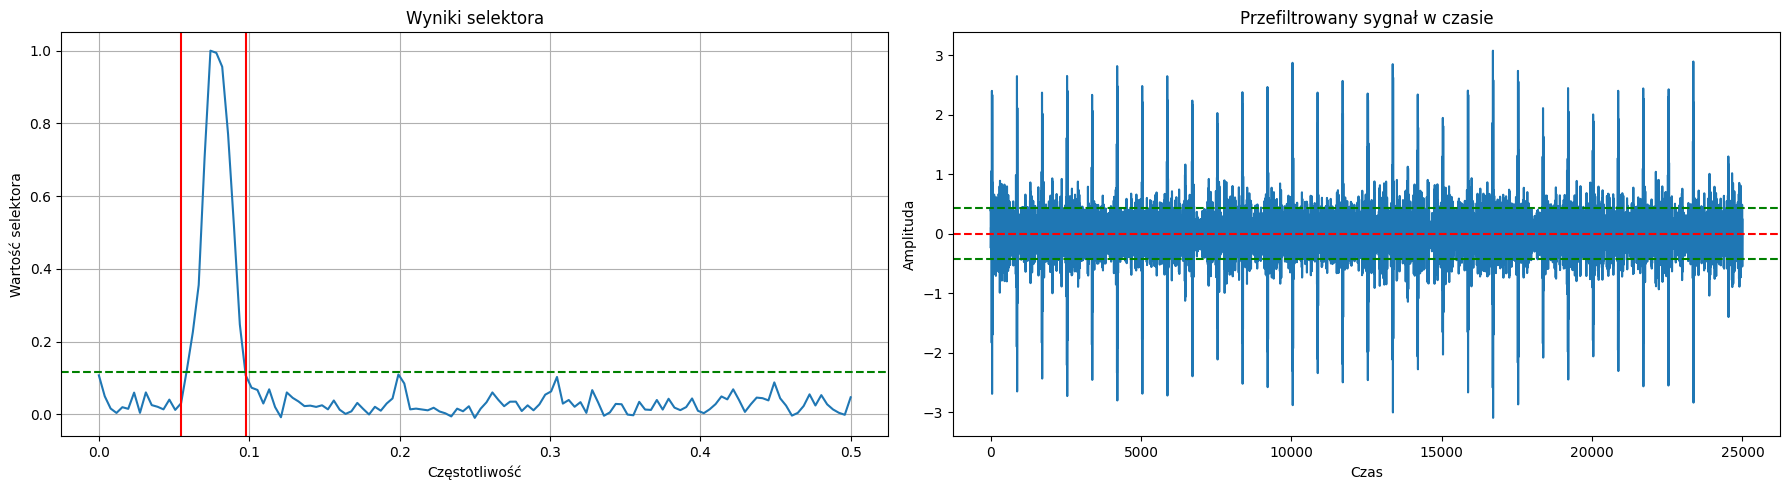

Dla selektora, średnia: 0.07268597699908665, odchylenie: 0.1762954697595279
Dla filtracji, średnia: 1.9539925233402756e-19, odchylenie: 0.4302077605045934
0.20825143652302075


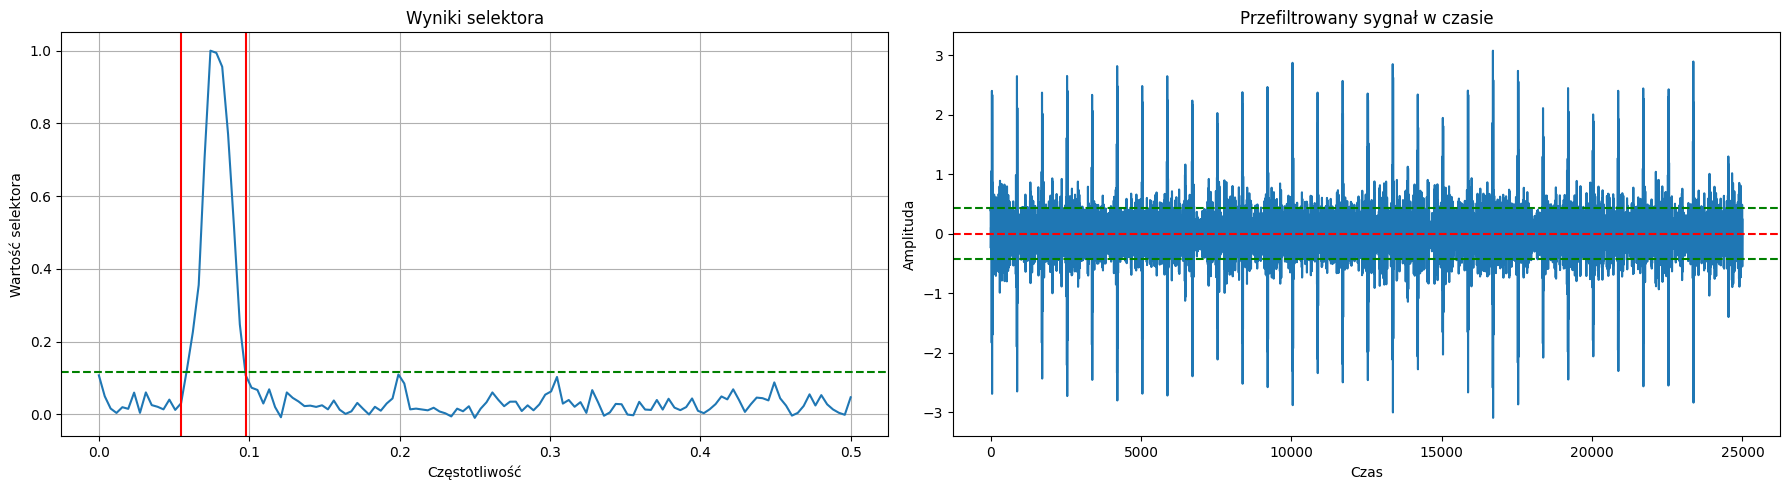

Dla selektora, średnia: 0.07268597699908665, odchylenie: 0.1762954697595279
Dla filtracji, średnia: 1.9539925233402756e-19, odchylenie: 0.4302077605045934
0.20825143652302075


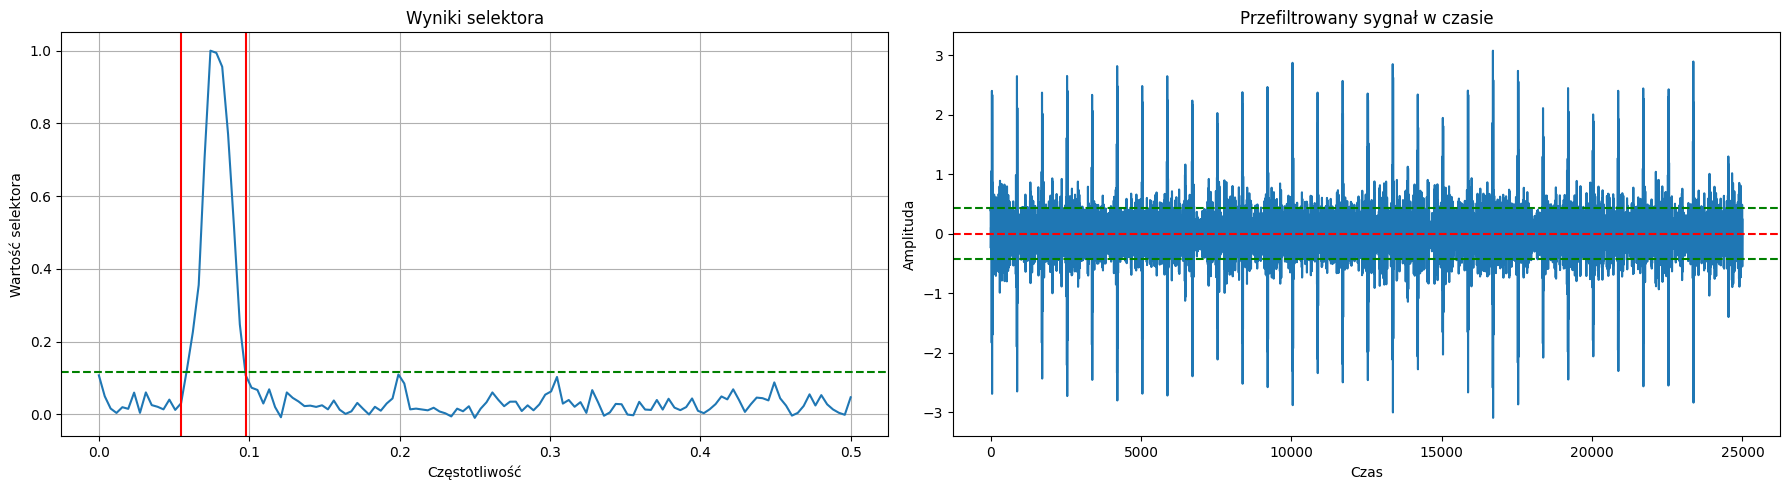

Dla selektora, średnia: 0.07268597699908665, odchylenie: 0.1762954697595279
Dla filtracji, średnia: 1.9539925233402756e-19, odchylenie: 0.4302077605045934
0.20825143652302075


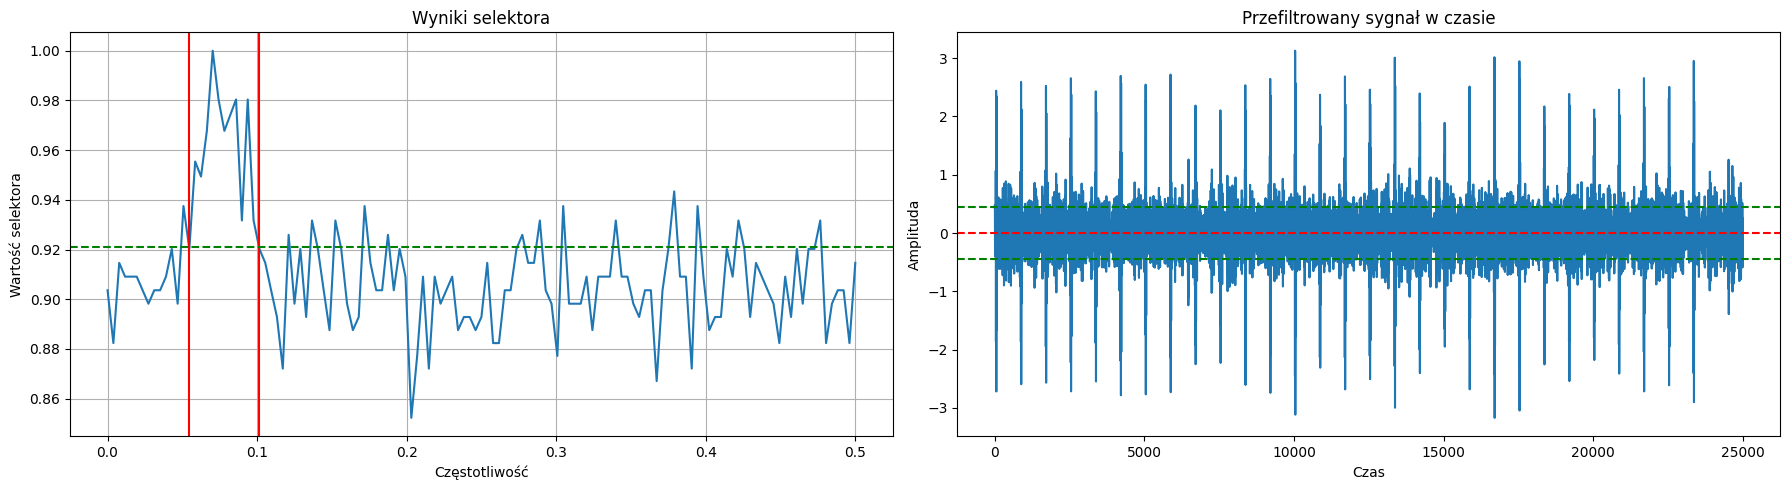

Dla selektora, średnia: 0.9103774085386593, odchylenie: 0.02374041295586825
Dla filtracji, średnia: -4.796163466380676e-19, odchylenie: 0.44002264912738215
0.20672728676298663


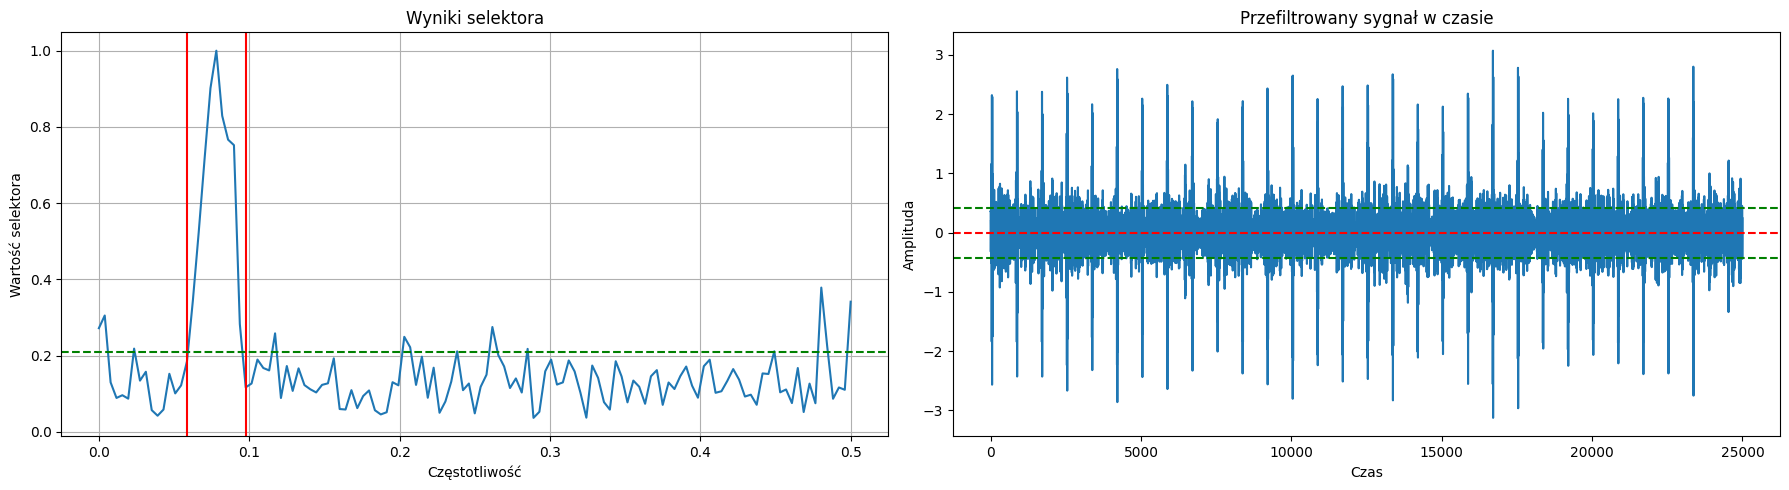

Dla selektora, średnia: 0.17182220655031197, odchylenie: 0.16321448825848855
Dla filtracji, średnia: -5.595524044110789e-19, odchylenie: 0.41994075284545107
0.20479116046864773


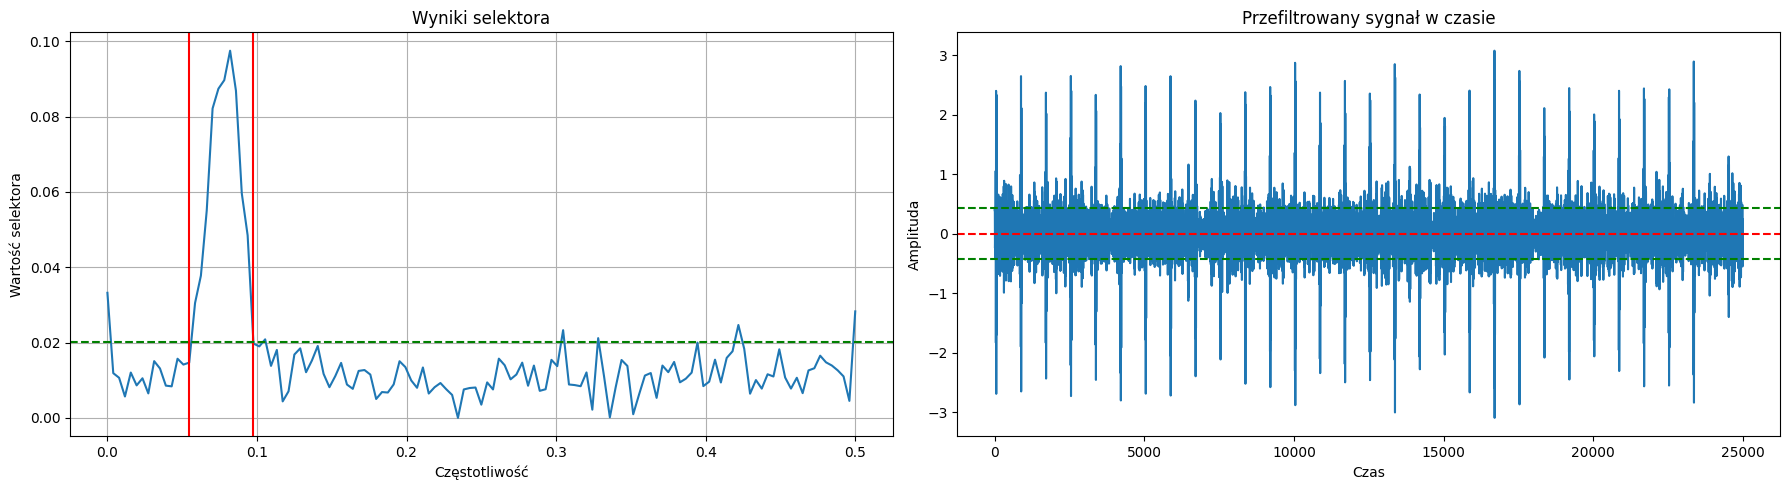

Dla selektora, średnia: 0.015951006214595973, odchylenie: 0.0170116990851749
Dla filtracji, średnia: 1.9539925233402756e-19, odchylenie: 0.4302077605045934
0.20825143652302075


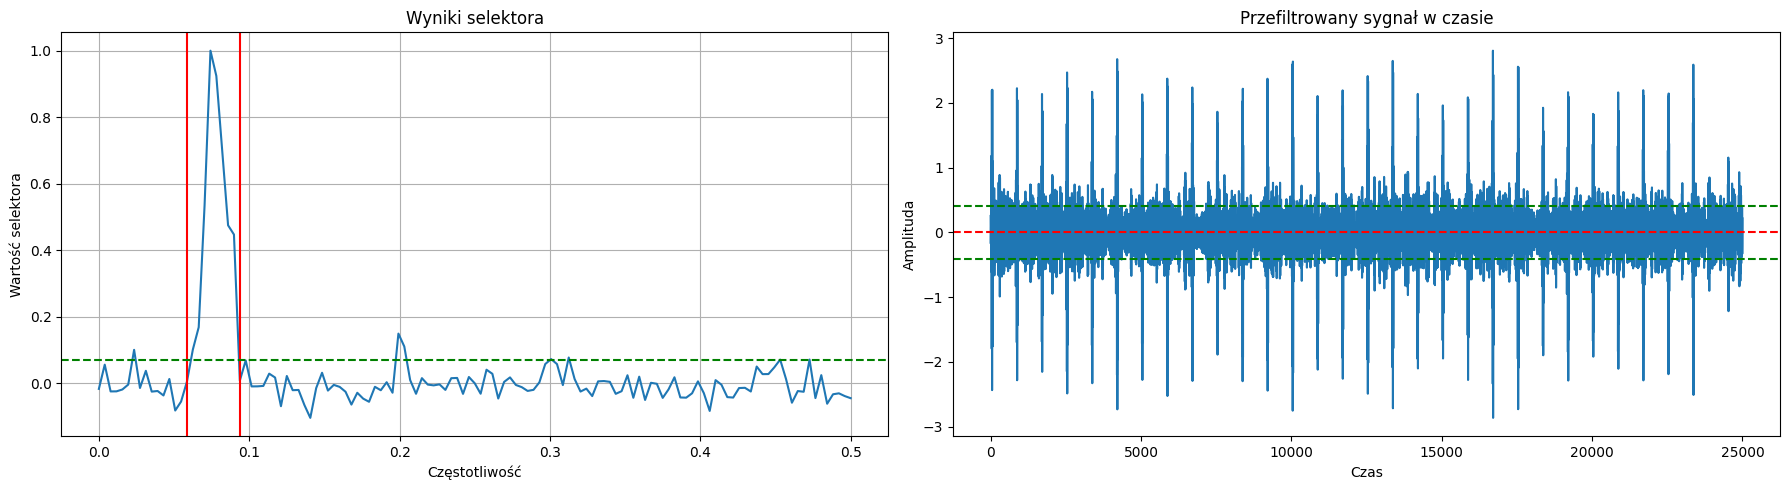

Dla selektora, średnia: 0.02791714348596847, odchylenie: 0.1572384388089812
Dla filtracji, średnia: 2.3092638912203254e-19, odchylenie: 0.40576420818802433
0.2087528758325962


In [7]:
import ifb_selectors as selector
filter_threshold = 1/2
impuls_threshold = 1
sk_results = selector.SK(Zxx)
print(selector_analysis(sk_results,filter_threshold,impuls_threshold))
jb_results = selector.JB(Zxx)
print(selector_analysis(sk_results,filter_threshold,impuls_threshold))
jb_results = selector.JB(Zxx)
print(selector_analysis(sk_results,filter_threshold,impuls_threshold))
kss_results = selector.KSS(Zxx)
print(selector_analysis(kss_results,filter_threshold,impuls_threshold))
ad_results = selector.AD(Zxx)
print(selector_analysis(ad_results,filter_threshold,impuls_threshold))
cvm_results = 1-selector.CVM(Zxx)
print(selector_analysis(cvm_results,filter_threshold,impuls_threshold))
cvs_results = selector.CVS(Zxx)
print(selector_analysis(cvs_results,filter_threshold,impuls_threshold))

# Analiza bez wykresów

In [8]:
import impuls_simulator as impuls_simulator
B=10
fs=25000
varsize=25000
fmod=30
f_center=2000
bandwidth=500
shift=0
sigma = 3
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)


def full_signal_analysis(selector,filter_threshold,impuls_threshold,B=10,fs=25000,varsize=25000,fmod=30,f_center=2000,bandwidth=500,shift=0,sigma = 3):
    signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)
    fs = 1
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx = np.abs(matrix_Zxx)

    results = selector(Zxx)
    left, right, threshold = spike_interval_by_peak(results,filter_threshold)

    #filtracja na podstawie otrzymanych granic
    filtered, _, _, _ = bandpass_filter(signal, fs, array_freq[left], array_freq[right])
    sigma = np.std(filtered)
    mu = np.mean(filtered)
    upper_threshold_filtered = mu + impuls_threshold*sigma
    lower_threshold_filtered = mu - impuls_threshold*sigma


    filtered_energy  = np.sum(filtered**2)
    impulses = (filtered > np.mean(filtered) + impuls_threshold*np.std(filtered)) | (filtered < np.mean(filtered) - impuls_threshold*np.std(filtered))

    filtered_no_impulses = filtered.copy()
    filtered_no_impulses[impulses] = 0
    filtered_no_impulses_energy = np.sum(filtered_no_impulses**2)
    # print(f"Dla selektora, średnia: {np.mean(results)}, odchylenie: {np.std(results)}")
    # print(f"Dla filtracji, średnia: {np.mean(filtered)}, odchylenie: {np.std(filtered)}")

    return filtered_no_impulses_energy/filtered_energy

In [9]:
import ifb_selectors as selector
filter_threshold = 1/2
impuls_threshold = 1
full_signal_analysis(selector.SK,filter_threshold,impuls_threshold,B=0)

np.float64(0.20340964932836916)

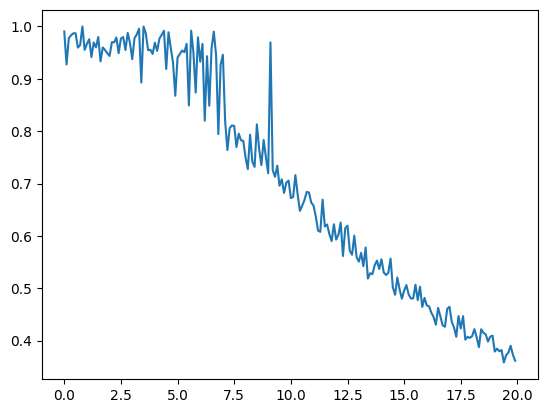

In [31]:
impuls_amps = np.arange(0,20,0.1)
results = np.zeros(len(impuls_amps))

filter_threshold = 1/2
impuls_threshold = 3



for i in range(len(impuls_amps)):
    results[i] = full_signal_analysis(selector.SK,filter_threshold,impuls_threshold,B=impuls_amps[i],fmod=13,sigma=5)

plt.plot(impuls_amps,results)